In [119]:
import requests
import pandas as pd

In [120]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

In [121]:
response = requests.get(url)
data = response.json()
print(data)

{'total_count': 1237929, 'incomplete_results': False, 'items': [{'id': 45717250, 'node_id': 'MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==', 'name': 'tensorflow', 'full_name': 'tensorflow/tensorflow', 'private': False, 'owner': {'login': 'tensorflow', 'id': 15658638, 'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE1NjU4NjM4', 'avatar_url': 'https://avatars.githubusercontent.com/u/15658638?v=4', 'gravatar_id': '', 'url': 'https://api.github.com/users/tensorflow', 'html_url': 'https://github.com/tensorflow', 'followers_url': 'https://api.github.com/users/tensorflow/followers', 'following_url': 'https://api.github.com/users/tensorflow/following{/other_user}', 'gists_url': 'https://api.github.com/users/tensorflow/gists{/gist_id}', 'starred_url': 'https://api.github.com/users/tensorflow/starred{/owner}{/repo}', 'subscriptions_url': 'https://api.github.com/users/tensorflow/subscriptions', 'organizations_url': 'https://api.github.com/users/tensorflow/orgs', 'repos_url': 'https://api.github.com/users/tensorflow/repos',

In [122]:
df = pd.DataFrame(data['items'])

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [124]:
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76116,2929,197556,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34340,2396,164399,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22061,13,89749,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15278,52,82640,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15621,27,74143,master,1.0


In [125]:
required_columns = [
    'name', 'owner', 'language', 'stargazers_count',
    'forks_count', 'watchers_count', 'open_issues_count',
    'created_at', 'updated_at', 'license'
]
df = df[required_columns]

In [126]:
df['owner'] = [x['login'] if x else None for x in df['owner']]
df['license'] = [x['name'] if x else None for x in df['license']]

In [127]:
print(df.isna().sum())
df['language'] = df['language'].fillna('Unknown')
df['license'] = df['license'].fillna('No License')

name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64


In [128]:
print(f"Duplicates count: {df.duplicated().sum()}")
df = df.drop_duplicates()

Duplicates count: 0


In [129]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

In [130]:
df.rename(columns={
    'stargazers_count': 'stars',
    'forks_count': 'forks',
    'watchers_count': 'watchers',
    'open_issues_count': 'open_issues',
    'created_at': 'created_date',
    'updated_at': 'updated_date'
}, inplace=True)

In [131]:
df.to_csv('github_projects.csv', index=False)

In [132]:
df_check = pd.read_csv('github_projects.csv')
print(df_check.head())
print(df_check.shape)

                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197556  76116   
1              transformers     huggingface            Python  164399  34340   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89749  22061   
3                    funNLP  fighting41love            Python   82640  15278   
4  awesome-machine-learning    josephmisiti            Python   74143  15621   

   watchers  open_issues               created_date  \
0    197556         2929  2015-11-07 01:19:20+00:00   
1    164399         2396  2018-10-29 13:56:00+00:00   
2     89749           13  2021-03-03 01:34:05+00:00   
3     82640           52  2018-08-21 11:20:39+00:00   
4     74143           27  2014-07-15 19:11:19+00:00   

                updated_date             license  
0  2026-08-24 19:18:21+00:00  Apache License 2.0  
1  2026-08-24 19:20:05+00:00  Apache License 2.0  
2  2026-08-24 18:34:40+00:00       

In [133]:
import sqlite3
import matplotlib.pyplot as plt

In [134]:
df = pd.read_csv('github_projects.csv')
conn = sqlite3.connect('github_data.db')

In [135]:
df.to_sql('Repositories', conn, if_exists='replace', index=False)

100

In [136]:
q1 = pd.read_sql_query("SELECT * FROM Repositories WHERE stars > 10000", conn)
print(q1)

                               name           owner          language   stars  \
0                        tensorflow      tensorflow               C++  197556   
1                      transformers     huggingface            Python  164399   
2                  ML-For-Beginners       microsoft  Jupyter Notebook   89749   
3                            funNLP  fighting41love            Python   82640   
4          awesome-machine-learning    josephmisiti            Python   74143   
..                              ...             ...               ...     ...   
65  machine-learning-systems-design       chiphuyen              HTML   10545   
66                 Machine-Learning    Jack-Cherish            Python   10373   
67           machine-learning-notes      roboticcam  Jupyter Notebook   10341   
68              3D-Machine-Learning     timzhang642           Unknown   10191   
69                             tpot    EpistasisLab  Jupyter Notebook   10052   

    forks  watchers  open_i

In [137]:
q2 = pd.read_sql_query("SELECT * FROM Repositories WHERE name LIKE '%Machine%'", conn)
print(q2)

                                                 name  \
0                            awesome-machine-learning   
1   500-AI-Machine-learning-Deep-learning-Computer...   
2             machine-learning-for-software-engineers   
3                           homemade-machine-learning   
4                 awesome-production-machine-learning   
5                        machine-learning-for-trading   
6                    stanford-cs-229-machine-learning   
7                          Machine-Learning-Tutorials   
8                           machine-learning-zoomcamp   
9                          machine-learning-interview   
10                       python-machine-learning-book   
11                         dive-into-machine-learning   
12                    machine-learning-systems-design   
13                                   Machine-Learning   
14                             machine-learning-notes   
15                                3D-Machine-Learning   
16                             

In [138]:
q3 = pd.read_sql_query("SELECT name, language, stars FROM Repositories WHERE stars > 5000 AND NOT language = 'Python'", conn)
print(q3)

                                                 name          language  \
0                                          tensorflow               C++   
1                                    ML-For-Beginners  Jupyter Notebook   
2   500-AI-Machine-learning-Deep-learning-Computer...           Unknown   
3                                         C-Plus-Plus               C++   
4                                              netron        JavaScript   
..                                                ...               ...   
65                    Machine-learning-learning-notes           Unknown   
66                                  awesome-youtubers          Markdown   
67                 Learn_Machine_Learning_in_3_Months           Unknown   
68                                              h2o-3  Jupyter Notebook   
69                          industry-machine-learning  Jupyter Notebook   

     stars  
0   197556  
1    89749  
2    36490  
3    34598  
4    33397  
..     ...  
65    77

In [139]:
q4 = pd.read_sql_query("SELECT name, language, stars FROM Repositories WHERE language = 'C++' OR language = 'Java'", conn)
print(q4)

                          name language   stars
0                   tensorflow      C++  197556
1                  C-Plus-Plus      C++   34598
2                       Paddle      C++   24062
3                      video2x      C++   21043
4                     LightGBM      C++   18710
5                         brpc      C++   17593
6                         ggml      C++   15221
7                      bullet3      C++   14692
8                         dlib      C++   14431
9   mit-deep-learning-book-pdf     Java   14212
10                  turicreate      C++   11159
11                    catboost      C++    9075
12               vowpal_wabbit      C++    8706


In [140]:
top10 = pd.read_sql_query("SELECT name, stars FROM Repositories ORDER BY stars DESC LIMIT 10", conn)
print(top10)

                                                name   stars
0                                         tensorflow  197556
1                                       transformers  164399
2                                   ML-For-Beginners   89749
3                                             funNLP   82640
4                           awesome-machine-learning   74143
5                                       scikit-learn   67055
6                                             gradio   43412
7  500-AI-Machine-learning-Deep-learning-Computer...   36490
8                                        C-Plus-Plus   34598
9                                             netron   33397


In [141]:
stats = pd.read_sql_query("SELECT COUNT(*), AVG(stars) FROM Repositories", conn)
print(stats)

   COUNT(*)  AVG(stars)
0       100    20830.65


In [142]:
group_data = pd.read_sql_query("SELECT language, COUNT(*) FROM Repositories GROUP BY language HAVING COUNT(*) > 5", conn)
print(group_data)

           language  COUNT(*)
0               C++        12
1  Jupyter Notebook        19
2            Python        30
3           Unknown        23


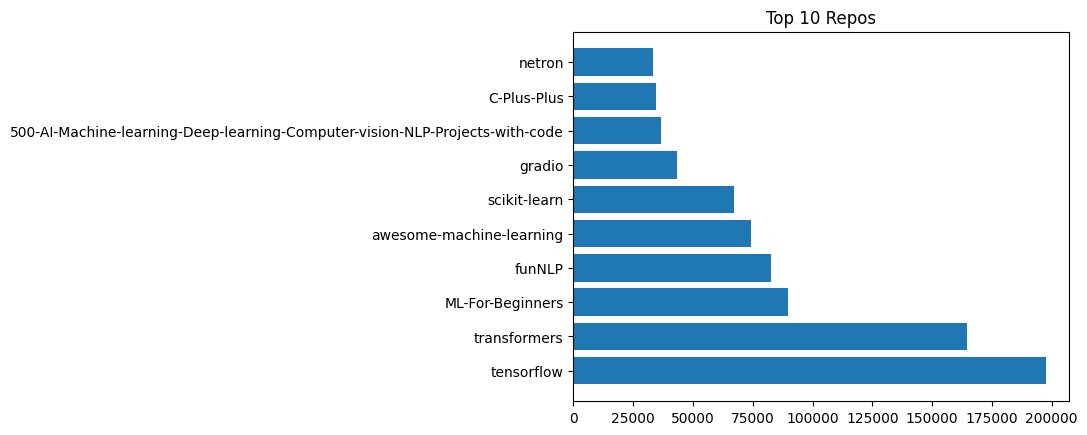

In [143]:
plt.barh(top10['name'], top10['stars'])
plt.title('Top 10 Repos')
plt.show()

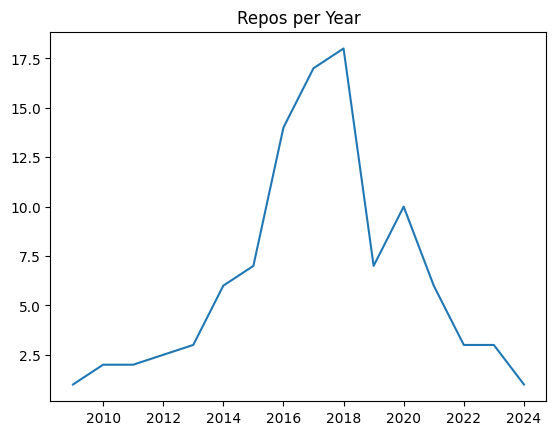

In [144]:
df['created_date'] = pd.to_datetime(df['created_date'])
years = df['created_date'].dt.year.value_counts().sort_index()
plt.plot(years.index, years.values)
plt.title('Repos per Year')
plt.show()
conn.close()

## Results Interpretation

* **Top Repos:** tensorflow is the most popular repository with around 197k stars, followed by transformers with around 164k stars.

* **Creation Trends:** The number of repositories created was highest in 2017 and 2018, with 17 repositories in 2017 and 18 in 2018. After 2020, the number of newly created repositories generally started to decrease.

* **Main Tools:** tensorflow, transformers, and scikit-learn have the highest star counts in the dataset. This shows that machine learning and deep learning projects are popular in the dataset.

* **Programming Languages:** Python is the most common language in the dataset with 30 repositories, followed by Jupyter Notebook with 19 and C++ with 12. There are also 23 repositories with an unknown language, which means that language information was not available for these repositories.
